# LightGBM Lead-Time Forecasting of Significant Wave Height (Hs) and Mean Wave Period (Te)

This notebook trains LightGBM models to forecast ocean parameters using ERA5 hourly ocean data. 
Targets to forecast:
- **Hs** (Significant Wave Height, corresponding to `swh` in the dataset)
- **Te** (Mean Wave Period, corresponding to `mwp` in the dataset)

Wave Power = 0.5 Hs^2 Te

Lead steps: 1h, 3h, 6h, 12h, 24h, 48h ahead.

Step 1:
- 1.1 Import Data
- 1.2 Train/Val/Test Split
- 1.3 Draw Power Matrix Plot
- 1.4 Draw Pearson Correlation Matrix

Step 2: 
- Feature builder
- Optimised Lagged value and K-features for each lead time
- Results: Performance indicator metrix + time series forecasting with 3 panels


### Step 1

1.1 Import Data

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

# Load ERA5 dataset
import os
try:
    script_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    script_dir = os.path.abspath('')
csv_path = os.path.join(script_dir, '..', '0_Data_Acquisition', '0_ERA5_Data', 'ERA5_Ocean_2024_01_to_2026_07.csv')
raw = pd.read_csv(csv_path, parse_dates=['valid_time'])
raw = raw.sort_values("valid_time").reset_index(drop=True)

# Forward-fill missing wave parameters just in case
raw = raw.ffill()

print("Loaded dataset shape:", raw.shape)

Loaded dataset shape: (39997, 20)


| **Variable**   | **Meaning (short & clear)**                             |
| -------------- | ------------------------------------------------------- |
| **valid_time** | Timestamp of the data (UTC).                            |
| **latitude**   | Latitude of the grid point.                             |
| **longitude**  | Longitude of the grid point.                            |
| **u10**        | 10‑m east–west wind component (positive = eastward).    |
| **v10**        | 10‑m north–south wind component (positive = northward). |
| **sst**        | Sea surface temperature.                                |
| **number**     | Ensemble member index (0–9).                            |
| **expver**     | Experiment version (internal ECMWF metadata).           |
| **tp**         | Total precipitation (m).                                |
| **mwd**        | Mean wave direction (all waves).                        |
| **mwp**        | Mean wave period (all waves).                           |
| **swh**        | Significant wave height (wind waves + swell).           |
| **mdts**       | Mean direction of total swell.                          |
| **mdww**       | Mean direction of wind waves.                           |
| **mpts**       | Mean period of total swell.                             |
| **mpww**       | Mean period of wind waves.                              |
| **wmb**        | Wind model  bathymetry                                  |
| **pp1d**       | Peak period (first moment). - peak wave period          |
| **shts**       | Significant height of total swell.                      |
| **shww**       | Significant height of wind waves.                       |

1.2 Walk-Forward (Rolling-Origin) Split

In [17]:
TARGETS = ["swh", "mwp"]  # swh = Hs, mwp = Te
LEAD_STEPS = [1, 3, 6, 12, 24, 48]  # Lead hours
N_LAGS = [1, 2, 3, 6, 12, 24, 48]

# Instead of one fixed train/valid/test cut, roll the valid+test window forward across
# the data in monthly steps, expanding the training window each time. This exposes how
# much a single fixed split's performance would depend on which season it happened to land on.
N_FOLDS = 6
VALID_WINDOW = pd.DateOffset(months=1)
TEST_WINDOW = pd.DateOffset(months=1)

In [18]:
t_idx = raw["valid_time"]
data_start = t_idx.min()
data_end = t_idx.max()

def build_walk_forward_folds(t_idx, data_start, data_end, n_folds, valid_window, test_window):
    """Expanding-window folds: test window rolls forward one step at a time over the
    most recent `n_folds` periods; training always uses everything before that fold's
    validation window, and validation sits directly before that fold's test window."""
    fold_test_ends = sorted(data_end - i * test_window for i in range(n_folds))
    folds = []
    for test_end in fold_test_ends:
        test_start = test_end - test_window + pd.Timedelta(hours=1)
        valid_end = test_start - pd.Timedelta(hours=1)
        valid_start = valid_end - valid_window + pd.Timedelta(hours=1)
        train_end = valid_start - pd.Timedelta(hours=1)

        train_mask = (t_idx >= data_start) & (t_idx <= train_end)
        valid_mask = (t_idx >= valid_start) & (t_idx <= valid_end)
        test_mask = (t_idx >= test_start) & (t_idx <= test_end)

        folds.append({
            "train_start": data_start, "train_end": train_end,
            "valid_start": valid_start, "valid_end": valid_end,
            "test_start": test_start, "test_end": test_end,
            "train_mask": train_mask, "valid_mask": valid_mask, "test_mask": test_mask,
        })
    return folds

folds = build_walk_forward_folds(t_idx, data_start, data_end, N_FOLDS, VALID_WINDOW, TEST_WINDOW)

for i, f in enumerate(folds, 1):
    print(f"Fold {i}: train [{f['train_start'].date()} -> {f['train_end'].date()}]  "
          f"valid [{f['valid_start'].date()} -> {f['valid_end'].date()}]  "
          f"test [{f['test_start'].date()} -> {f['test_end'].date()}]  "
          f"(n_train={f['train_mask'].sum()}, n_valid={f['valid_mask'].sum()}, n_test={f['test_mask'].sum()})")

# The rest of the notebook (Step 2 onward) is written against a single train_m/valid_m/test_m
# split, so point those at the most recent fold by default. `folds` still holds every rolling
# window if a cell wants to loop the whole pipeline across all of them (see 2.5).
active_fold = folds[-1]
train_m, valid_m, test_m = active_fold["train_mask"], active_fold["valid_mask"], active_fold["test_mask"]

print(f"\nActive fold (most recent, used by default below): "
      f"train={train_m.sum()} valid={valid_m.sum()} test={test_m.sum()}")

Fold 1: train [2022-01-01 -> 2025-12-25]  valid [2025-12-25 -> 2026-01-25]  test [2026-01-25 -> 2026-02-25]  (n_train=34909, n_valid=744, n_test=744)
Fold 2: train [2022-01-01 -> 2026-01-25]  valid [2026-01-25 -> 2026-02-25]  test [2026-02-25 -> 2026-03-25]  (n_train=35653, n_valid=744, n_test=672)
Fold 3: train [2022-01-01 -> 2026-02-25]  valid [2026-02-25 -> 2026-03-25]  test [2026-03-25 -> 2026-04-25]  (n_train=36397, n_valid=672, n_test=744)
Fold 4: train [2022-01-01 -> 2026-03-25]  valid [2026-03-25 -> 2026-04-25]  test [2026-04-25 -> 2026-05-25]  (n_train=37069, n_valid=744, n_test=720)
Fold 5: train [2022-01-01 -> 2026-04-25]  valid [2026-04-25 -> 2026-05-25]  test [2026-05-25 -> 2026-06-25]  (n_train=37813, n_valid=720, n_test=744)
Fold 6: train [2022-01-01 -> 2026-05-25]  valid [2026-05-25 -> 2026-06-25]  test [2026-06-25 -> 2026-07-25]  (n_train=38533, n_valid=744, n_test=720)

Active fold (most recent, used by default below): train=38533 valid=744 test=720


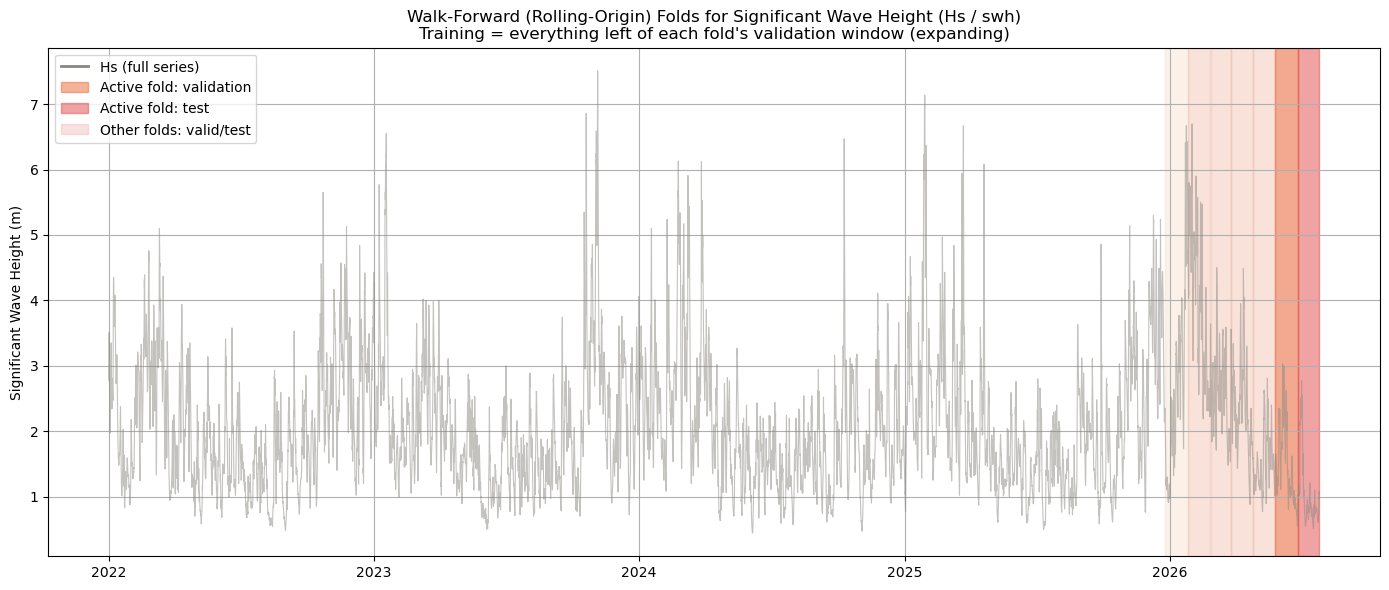

In [19]:
print("\n--- Step 1: Data Visualization and Profiling ---")
print("1. Plotting Walk-Forward Folds...")
# Show every rolling fold's train/valid/test windows against Hs, plus the active (most recent) fold highlighted
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(t_idx, raw["swh"], color="#898781", alpha=0.5, linewidth=0.8, label="Hs (full series)")

for i, f in enumerate(folds, 1):
    is_active = (f is active_fold)
    valid_color = "#eb6834" if is_active else "#f0c8ab"
    test_color = "#e34948" if is_active else "#f0b3b2"
    ax.axvspan(f["valid_start"], f["valid_end"], color=valid_color, alpha=0.5 if is_active else 0.25)
    ax.axvspan(f["test_start"], f["test_end"], color=test_color, alpha=0.5 if is_active else 0.25)

ax.set_title("Walk-Forward (Rolling-Origin) Folds for Significant Wave Height (Hs / swh)\n"
              "Training = everything left of each fold's validation window (expanding)")
ax.set_ylabel("Significant Wave Height (m)")
ax.legend(handles=[
    plt.Line2D([0], [0], color="#898781", lw=2, label="Hs (full series)"),
    plt.Rectangle((0, 0), 1, 1, color="#eb6834", alpha=0.5, label="Active fold: validation"),
    plt.Rectangle((0, 0), 1, 1, color="#e34948", alpha=0.5, label="Active fold: test"),
    plt.Rectangle((0, 0), 1, 1, color="#f0b3b2", alpha=0.4, label="Other folds: valid/test"),
])
ax.grid(True)
plt.tight_layout()
plt.show()

1.3 Power Matrix

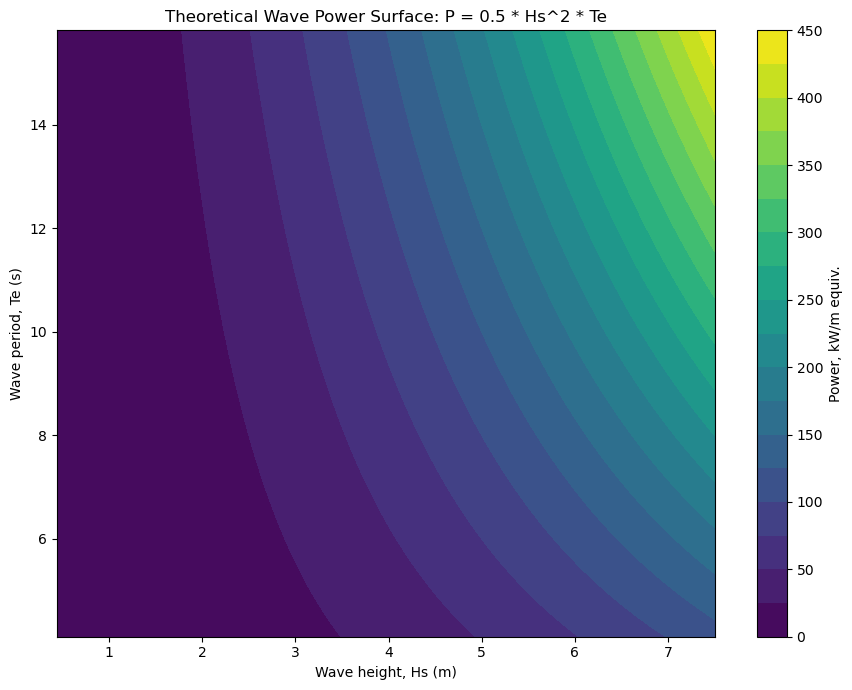

In [20]:
print("2. Plotting Theoretical Wave Power Surface & Matrix...")
# Raw theoretical Wave Power surface: P = 0.5 * Hs^2 * Te (no occurrence weighting)
# Grid spans the actual Hs/Te range observed in your ERA5 data (raw["swh"], raw["mwp"])
Hs_data = raw["swh"]
Te_data = raw["mwp"]

hs_range = np.linspace(max(Hs_data.min(), 0.1), Hs_data.max(), 200)
te_range = np.linspace(max(Te_data.min(), 0.1), Te_data.max(), 200)
Hs_grid, Te_grid = np.meshgrid(hs_range, te_range)
P_grid = 0.5 * Hs_grid ** 2 * Te_grid

fig, ax = plt.subplots(figsize=(9, 7))
cf = ax.contourf(Hs_grid, Te_grid, P_grid, levels=20, cmap="viridis")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Power, kW/m equiv.")

ax.set_xlabel("Wave height, Hs (m)")
ax.set_ylabel("Wave period, Te (s)")
ax.set_title("Theoretical Wave Power Surface: P = 0.5 * Hs^2 * Te")
plt.tight_layout()
plt.show()

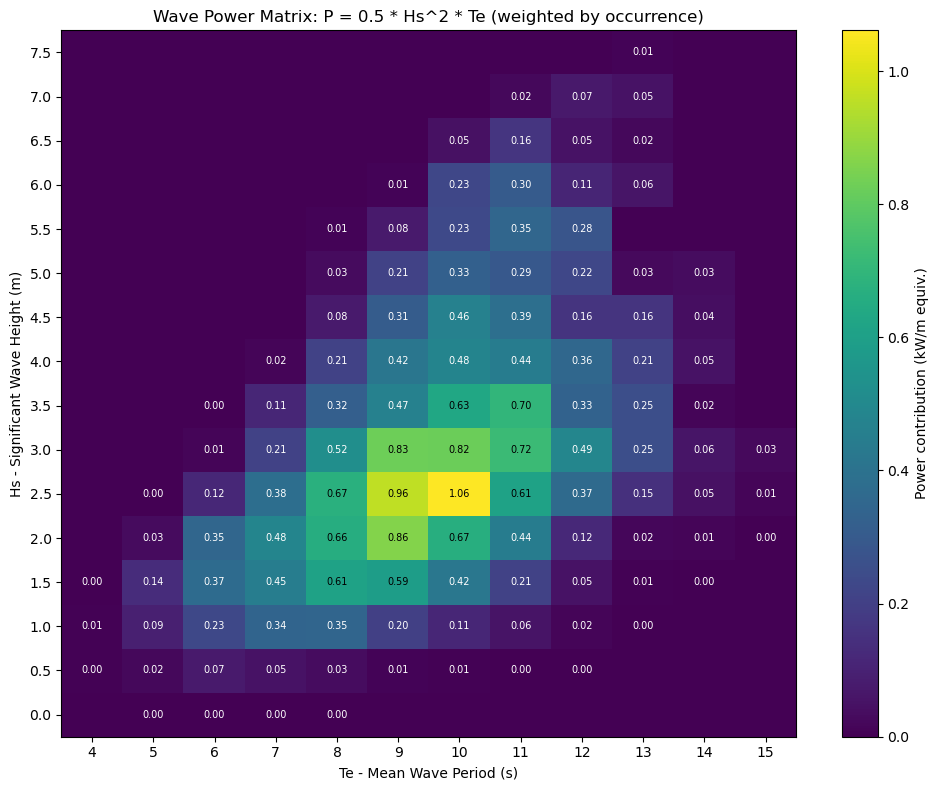

In [21]:
# Wave Power Matrix: P = 0.5 * Hs^2 * Te
Hs = raw["swh"]
Te = raw["mwp"]

# Bin edges for Hs (m) and Te (s)
hs_edges = np.arange(0, np.ceil(Hs.max()) + 0.5, 0.5)
te_edges = np.arange(0, np.ceil(Te.max()) + 1, 1)

hs_bins = pd.cut(Hs, bins=hs_edges, right=False)
te_bins = pd.cut(Te, bins=te_edges, right=False)

# Bin-centre power value: 0.5 * Hs_mid^2 * Te_mid
hs_mid = hs_edges[:-1] + np.diff(hs_edges) / 2
te_mid = te_edges[:-1] + np.diff(te_edges) / 2
power_grid = 0.5 * (hs_mid[:, None] ** 2) * te_mid[None, :]

# Occurrence (%) of observations in each Hs-Te bin
occurrence = pd.crosstab(hs_bins, te_bins).reindex(
    index=pd.cut(pd.Series(hs_mid), bins=hs_edges, right=False).cat.categories,
    columns=pd.cut(pd.Series(te_mid), bins=te_edges, right=False).cat.categories,
    fill_value=0,
)
occurrence_pct = 100 * occurrence / occurrence.values.sum()

# Power matrix weighted by occurrence (contribution to total resource)
power_matrix = power_grid * (occurrence_pct.values / 100)

# Trim empty rows/cols for a cleaner plot
row_mask = occurrence.values.sum(axis=1) > 0
col_mask = occurrence.values.sum(axis=0) > 0
hs_labels = [f"{e:.1f}" for e in hs_edges[:-1][row_mask]]
te_labels = [f"{e:.0f}" for e in te_edges[:-1][col_mask]]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(power_matrix[row_mask][:, col_mask], cmap="viridis", origin="lower", aspect="auto")

ax.set_xticks(np.arange(len(te_labels)))
ax.set_yticks(np.arange(len(hs_labels)))
ax.set_xticklabels(te_labels)
ax.set_yticklabels(hs_labels)
ax.set_xlabel("Te - Mean Wave Period (s)")
ax.set_ylabel("Hs - Significant Wave Height (m)")
ax.set_title("Wave Power Matrix: P = 0.5 * Hs^2 * Te (weighted by occurrence)")

vals = power_matrix[row_mask][:, col_mask]
thresh = vals.max() / 2 if vals.max() > 0 else 0
for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        if vals[i, j] > 0:
            ax.text(j, i, f"{vals[i, j]:.2f}", ha="center", va="center",
                    color="white" if vals[i, j] < thresh else "black", fontsize=7)

fig.colorbar(im, ax=ax, label="Power contribution (kW/m equiv.)")
plt.tight_layout()
plt.show()

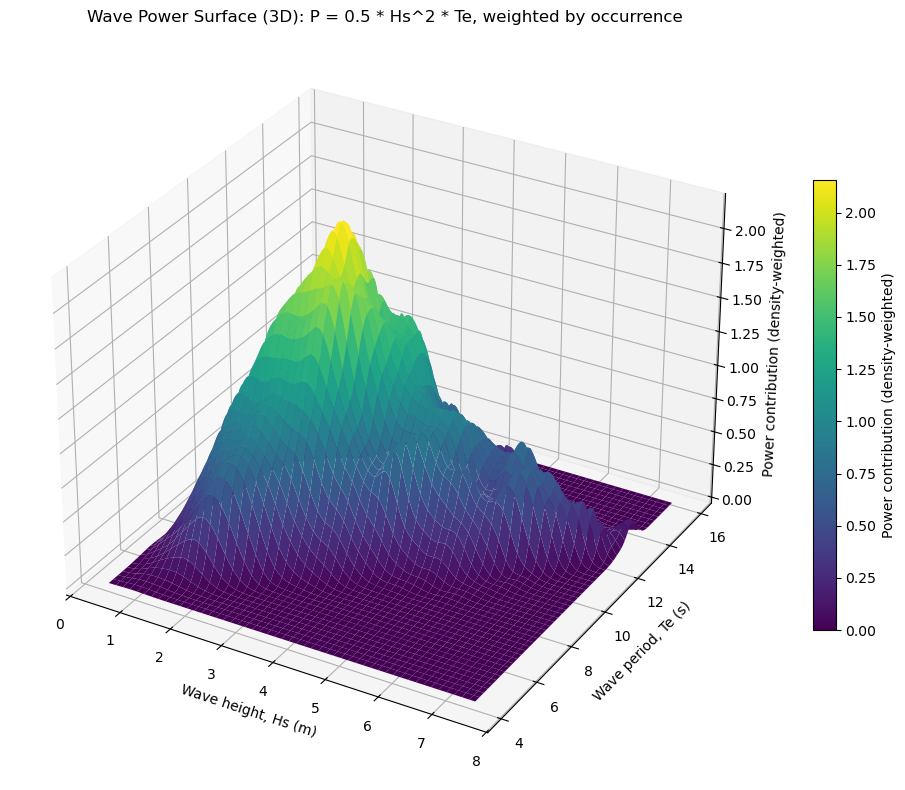

In [22]:
# Wave Power Surface in 3D: P = 0.5 * Hs^2 * Te, smoothed & weighted by occurrence
# Occurrence is estimated with a 2D Gaussian KDE over the actual (Hs, Te) observations,
# giving a smooth density instead of discrete bin counts.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.stats import gaussian_kde

Hs_data = raw["swh"]
Te_data = raw["mwp"]

hs_range = np.linspace(max(Hs_data.min(), 0.1), Hs_data.max(), 200)
te_range = np.linspace(max(Te_data.min(), 0.1), Te_data.max(), 200)
Hs_grid, Te_grid = np.meshgrid(hs_range, te_range)

# Smooth occurrence density (integrates to ~1 over the domain)
print("3. Calculating 2D Gaussian KDE for 3D Power Surface (this will take a few minutes)...")
kde = gaussian_kde(np.vstack([Hs_data, Te_data]))
density = kde(np.vstack([Hs_grid.ravel(), Te_grid.ravel()])).reshape(Hs_grid.shape)
print("   KDE calculation completed.")

# Theoretical power at each point, weighted by how often that sea state occurs
P_grid = 0.5 * Hs_grid ** 2 * Te_grid
weighted_surface = P_grid * density

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(Hs_grid, Te_grid, weighted_surface, cmap="viridis", linewidth=0, antialiased=True)

ax.set_xlabel("Wave height, Hs (m)")
ax.set_ylabel("Wave period, Te (s)")
ax.set_zlabel("Power contribution (density-weighted)")
ax.set_title("Wave Power Surface (3D): P = 0.5 * Hs^2 * Te, weighted by occurrence")

fig.colorbar(surf, ax=ax, shrink=0.6, label="Power contribution (density-weighted)")
plt.tight_layout()
plt.show()

1.5 Pearson Correlation Matrix heatmap

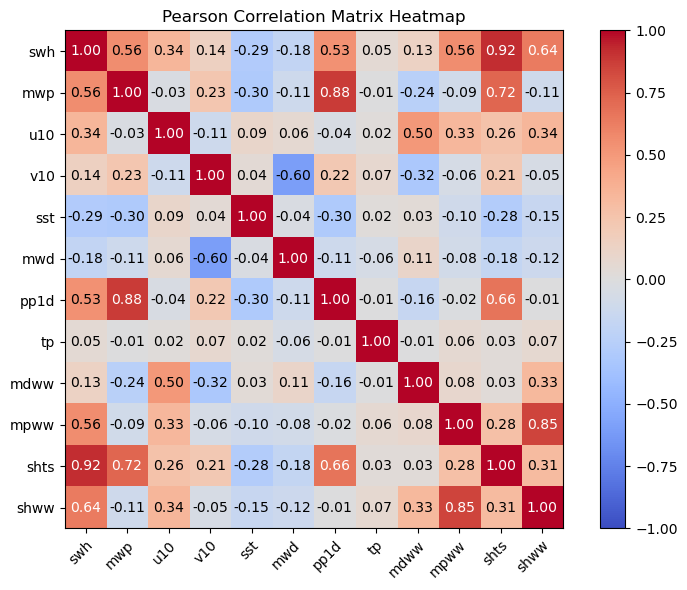

In [23]:
# Pearson Correlation Matrix heatmap using matplotlib
corr_cols = ["swh", "mwp", "u10", "v10", "sst", "mwd", "pp1d", "tp", "mdww", "mpww", "shts", "shww"]
corr_matrix = raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols)
ax.set_yticklabels(corr_cols)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        text = ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                       ha="center", va="center", color="black" if abs(corr_matrix.iloc[i, j]) < 0.6 else "white")

ax.set_title("Pearson Correlation Matrix Heatmap")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### Step 2

2.1 Feature Builder

In [24]:
# Feature builder with lag time
# N_LAGS runs [0, 48] (sparse, not dense, lags) so we can later choose the suitable lag time per lead step
N_LAGS = [0, 1, 3, 6, 12, 24, 48]

def build_features(df):
    feat_dict = {}
    feat_dict["hour_sin"] = np.sin(2 * np.pi * df["valid_time"].dt.hour / 24)
    feat_dict["hour_cos"] = np.cos(2 * np.pi * df["valid_time"].dt.hour / 24)
    feat_dict["doy_sin"] = np.sin(2 * np.pi * df["valid_time"].dt.dayofyear / 365.25)
    feat_dict["doy_cos"] = np.cos(2 * np.pi * df["valid_time"].dt.dayofyear / 365.25)

    cols_to_lag = [c for c in df.columns if c not in ["valid_time", "latitude", "longitude", "number", "expver", "wmb", "tp"]]
    for col in cols_to_lag:
        feat_dict[col] = df[col]
        for lag in N_LAGS:
            feat_dict[f"{col}_lag{lag}"] = df[col].shift(lag)

    return pd.DataFrame(feat_dict, index=df.index)

features_all = build_features(raw)


2.2 Lagged value optimisation

In [25]:
LAG_SEARCH_RANGE = range(0, 49, 1)  # dense: every lag from 0h to 48h

EXCLUDE_COLS = ["valid_time", "latitude", "longitude", "number", "expver", "wmb", "tp"]
candidate_cols = [c for c in raw.columns if c not in EXCLUDE_COLS]

def find_best_lag(series, target_series, lag_range, mask):
    best_lag, best_corr = lag_range[0], -np.inf
    for lag in lag_range:
        shifted = series.shift(lag)
        valid = mask & shifted.notna() & target_series.notna()
        if valid.sum() < 40:
            continue
        corr = abs(np.corrcoef(shifted[valid], target_series[valid])[0, 1])
        if corr > best_corr:
            best_corr, best_lag = corr, lag
    return best_lag, best_corr

# best_lags[target][lead][col] = {"lag": ..., "corr": ...}
best_lags = {}
for target in TARGETS:
    best_lags[target] = {}
    for lead in LEAD_STEPS:
        print(f"Optimising lags for target={target}, lead={lead}h...")
        future_target = raw[target].shift(-lead)
        lag_results = {}
        for col in candidate_cols:
            lag, corr = find_best_lag(raw[col], future_target, LAG_SEARCH_RANGE, train_m)
            lag_results[col] = {"lag": lag, "corr": corr}
        best_lags[target][lead] = lag_results

# Preview: best lag choice per variable, forecasting Hs 24h ahead
pd.DataFrame(best_lags["swh"][24]).T.sort_values("corr", ascending=False)
# pd.DataFrame(best_lags["mwp"][48]).T.sort_values("corr", ascending=False)

,lag,corr
swh,0.0,0.756403
shts,0.0,0.694445
mpts,0.0,0.574184
shww,0.0,0.498391
mwp,0.0,0.429148
mpww,0.0,0.428000
pp1d,0.0,0.421099
u10,0.0,0.334536
v10,13.0,0.329750
mdts,0.0,0.278638


2.3 Optimise K features

In [26]:
RFE_STEP_SIZE = 5   # number of weakest features dropped per iteration
RFE_MIN_FEATURES = 1

def evaluate_rfe(target, lead, step_size=RFE_STEP_SIZE, min_features=RFE_MIN_FEATURES):
    def build_lead_features(target, lead):
        X = features_all.copy()
        y = raw[target].shift(-lead)
        return X, y
    X, y = build_lead_features(target, lead)
    valid_rows = X.notna().all(axis=1) & y.notna()

    X_train, y_train = X[train_m & valid_rows], y[train_m & valid_rows]
    X_valid, y_valid = X[valid_m & valid_rows], y[valid_m & valid_rows]

    current_features = list(X.columns)
    history = []

    while True:
        print(f"  RFE: Evaluating model with {len(current_features)} features...")
        model = lgb.LGBMRegressor(random_state=42, verbose=-1)
        model.fit(X_train[current_features], y_train)
        pred = model.predict(X_valid[current_features])

        history.append({
            "n_features": len(current_features),
            "features": tuple(current_features),
            "rmse": np.sqrt(mean_squared_error(y_valid, pred)),
            "mape": mean_absolute_percentage_error(y_valid, pred),
            "r2": r2_score(y_valid, pred),
        })

        if len(current_features) <= min_features:
            break

        # Recursive step: re-rank remaining features by this model's importances, drop the weakest
        importances = model.feature_importances_
        weakest_idx = np.argsort(importances)[:min(step_size, len(current_features) - min_features)]
        weakest = [current_features[i] for i in weakest_idx]
        current_features = [f for f in current_features if f not in weakest]

    history_df = pd.DataFrame(history)
    best_idx = history_df["r2"].idxmax()
    best_row = history_df.loc[best_idx]
    return history_df, best_row

rfe_results = {}
for target in TARGETS:
    rfe_results[target] = {}
    for lead in LEAD_STEPS:
        print(f"Running RFE for target={target}, lead={lead}h...")
        history_df, best_row = evaluate_rfe(target, lead)
        rfe_results[target][lead] = {"history": history_df, "best": best_row}
        print(f"{target} | lead={lead}h -> best n_features={best_row['n_features']}, "
              f"RMSE={best_row['rmse']:.4f}, MAPE={best_row['mape']:.4f}, R2={best_row['r2']:.4f}")

swh | lead=1h -> best n_features=68, RMSE=0.0198, MAPE=0.0102, R2=0.9989
swh | lead=3h -> best n_features=58, RMSE=0.0526, MAPE=0.0287, R2=0.9921
swh | lead=6h -> best n_features=53, RMSE=0.1143, MAPE=0.0627, R2=0.9632
swh | lead=12h -> best n_features=63, RMSE=0.2431, MAPE=0.1402, R2=0.8345
swh | lead=24h -> best n_features=68, RMSE=0.4001, MAPE=0.2605, R2=0.5556
swh | lead=48h -> best n_features=108, RMSE=0.5385, MAPE=0.3793, R2=0.2012
mwp | lead=1h -> best n_features=18, RMSE=0.0638, MAPE=0.0060, R2=0.9981
mwp | lead=3h -> best n_features=48, RMSE=0.1996, MAPE=0.0194, R2=0.9815
mwp | lead=6h -> best n_features=58, RMSE=0.4091, MAPE=0.0392, R2=0.9216
mwp | lead=12h -> best n_features=58, RMSE=0.7441, MAPE=0.0739, R2=0.7350
mwp | lead=24h -> best n_features=108, RMSE=1.1389, MAPE=0.1164, R2=0.3357
mwp | lead=48h -> best n_features=83, RMSE=1.3202, MAPE=0.1448, R2=-0.0196


2.4 Run on Test Set

In [27]:
train_valid_m = train_m | valid_m

def train_final_model(target, lead):
    best_features = list(rfe_results[target][lead]["best"]["features"])

    def build_lead_features(target, lead):
        X = features_all.copy()
        y = raw[target].shift(-lead)
        return X, y

    X, y = build_lead_features(target, lead)
    valid_rows = X.notna().all(axis=1) & y.notna()

    X_fit, y_fit = X[train_valid_m & valid_rows], y[train_valid_m & valid_rows]
    X_test, y_test = X[test_m & valid_rows], y[test_m & valid_rows]
    t_test = raw["valid_time"][test_m & valid_rows]

    model = lgb.LGBMRegressor(random_state=42, verbose=-1)
    model.fit(X_fit[best_features], y_fit)
    pred = model.predict(X_test[best_features])

    return t_test.values, y_test.values, pred, best_features

results_table = []
predictions = {}
for target in TARGETS:
    for lead in LEAD_STEPS:
        tt, actual, pred, feats = train_final_model(target, lead)
        predictions[(target, lead)] = (tt, actual, pred)

        results_table.append({
            "target": target,
            "lead_h": lead,
            "n_features": len(feats),
            "MAE": mean_absolute_error(actual, pred),
            "RMSE": np.sqrt(mean_squared_error(actual, pred)),
            "MAPE": mean_absolute_percentage_error(actual, pred),
            "R2": r2_score(actual, pred),
        })

results_df = pd.DataFrame(results_table)
results_df

,target,lead_h,n_features,MAE,RMSE,MAPE,R2
0,swh,1,68,0.014593,0.020534,0.015274,0.998463
1,swh,3,58,0.041061,0.057187,0.040451,0.988106
2,swh,6,53,0.087627,0.115705,0.091016,0.951453
3,swh,12,63,0.212409,0.255303,0.237347,0.765478
4,swh,24,68,0.396888,0.447234,0.461258,0.292504
5,swh,48,108,0.662536,0.697033,0.793339,-0.662531
6,mwp,1,18,0.053709,0.084055,0.009302,0.992471
7,mwp,3,48,0.152390,0.205629,0.025771,0.954894
8,mwp,6,58,0.315377,0.406008,0.053312,0.823603
9,mwp,12,58,0.564607,0.706264,0.094883,0.462554


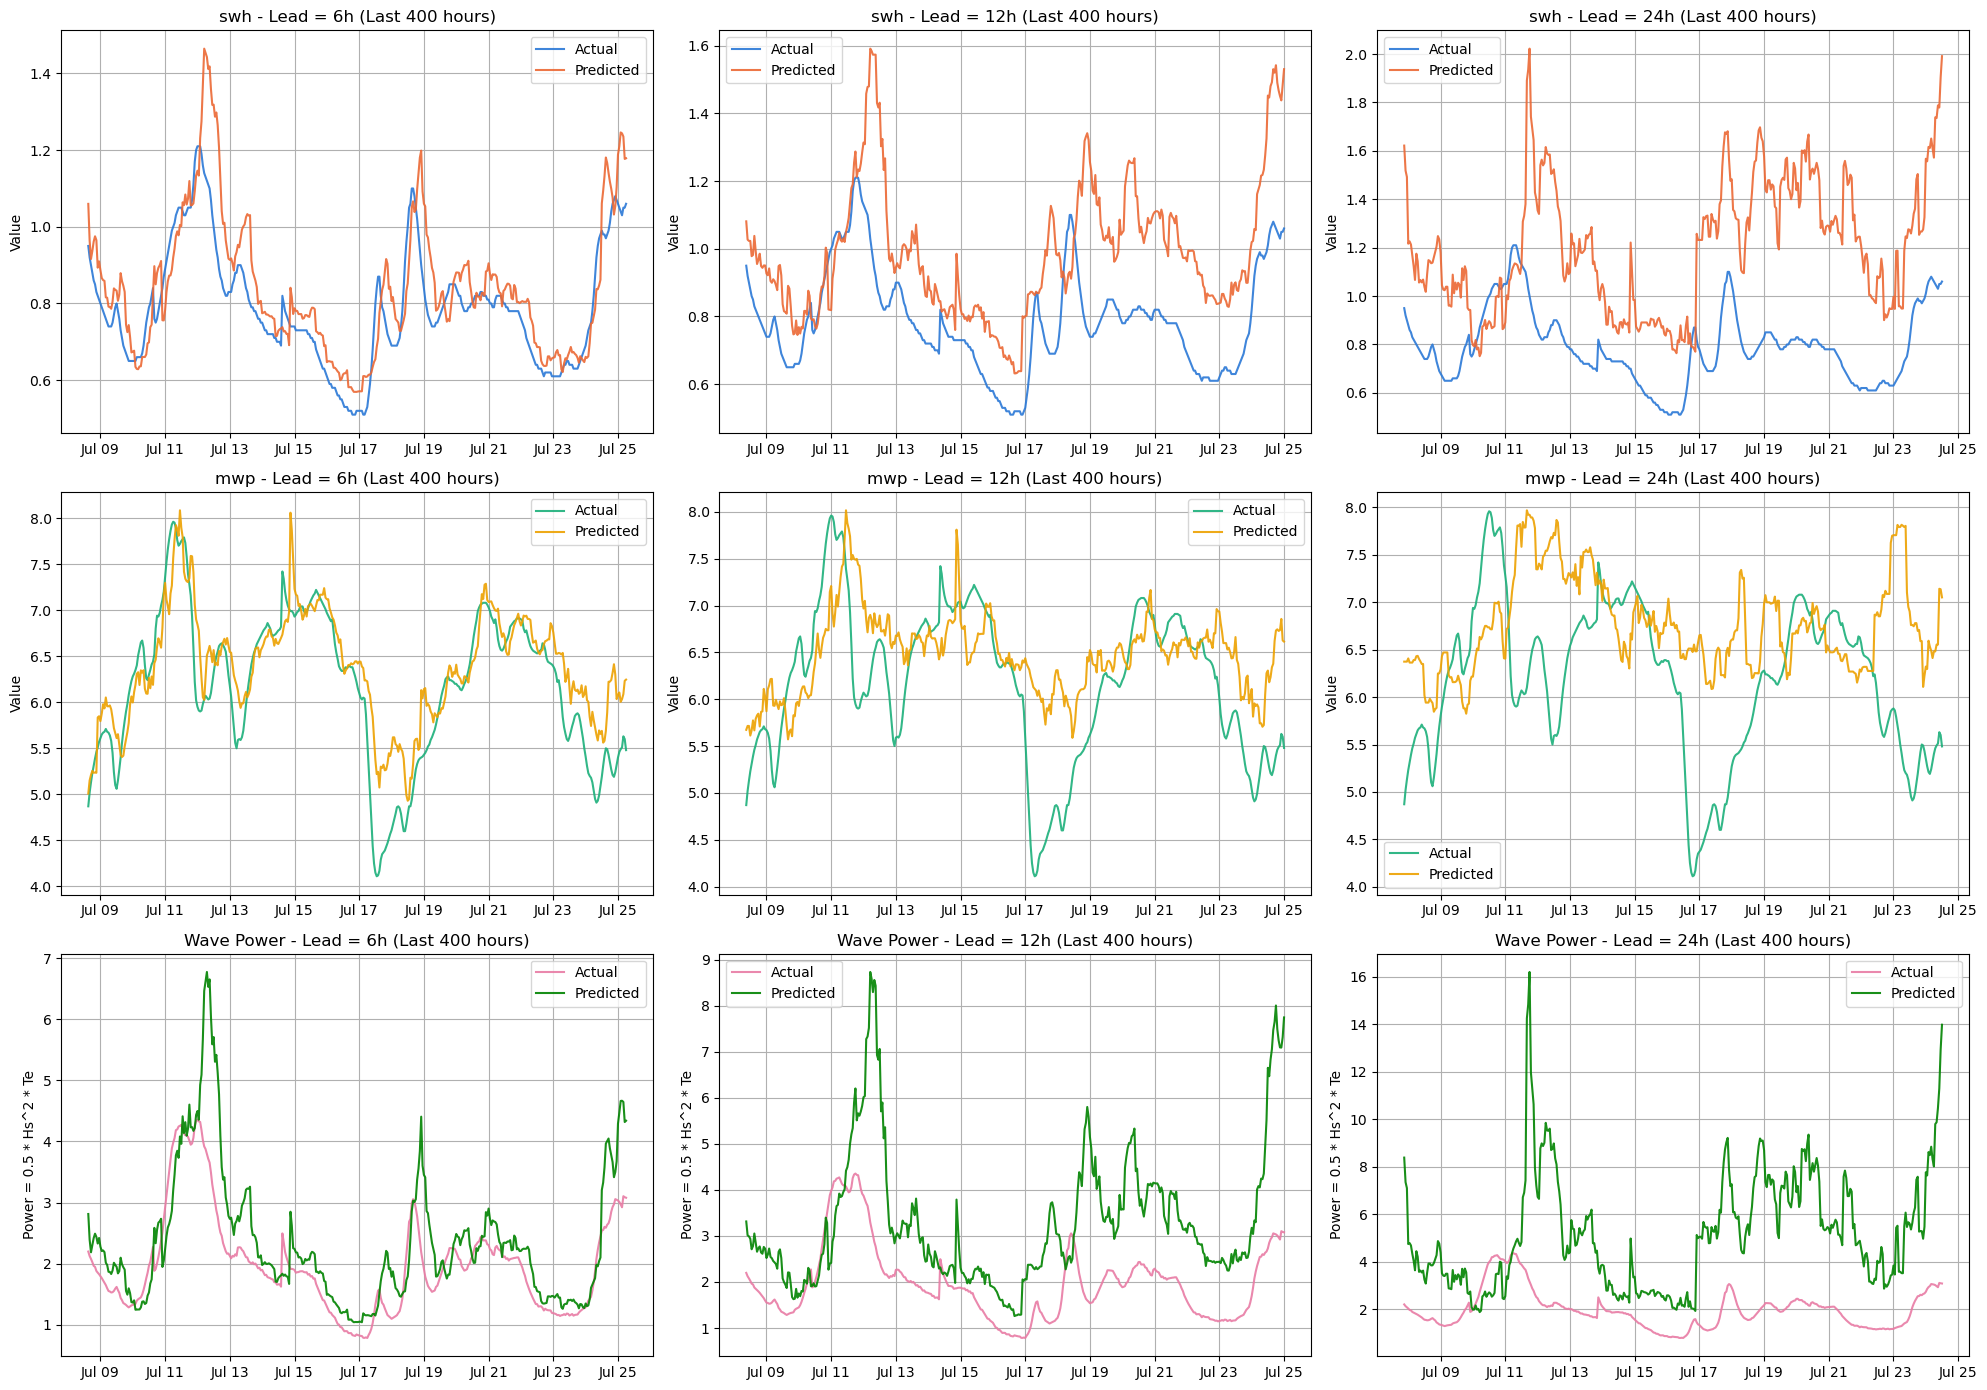

In [28]:
import matplotlib.dates as mdates

# One validated colorblind-safe Actual/Predicted pair per row (adjacent slots from the categorical palette)
ROW_COLORS = {
    "swh": {"actual": "#2a78d6", "predicted": "#eb6834"},        # blue / orange
    "mwp": {"actual": "#1baf7a", "predicted": "#eda100"},        # aqua / yellow
    "wave_power": {"actual": "#e87ba4", "predicted": "#008300"}, # magenta / green
}

plot_leads = [6,12,24]

def compute_power_series(lead):
    tt_h, actual_h, pred_h = predictions[("swh", lead)]
    tt_t, actual_t, pred_t = predictions[("mwp", lead)]

    # Hs and Te predictions can have slightly different valid timestamps, align on the overlap
    s_actual_h = pd.Series(actual_h, index=tt_h)
    s_pred_h = pd.Series(pred_h, index=tt_h)
    s_actual_t = pd.Series(actual_t, index=tt_t)
    s_pred_t = pd.Series(pred_t, index=tt_t)

    common_idx = s_actual_h.index.intersection(s_actual_t.index).sort_values()

    actual_power = 0.5 * s_actual_h.loc[common_idx].values ** 2 * s_actual_t.loc[common_idx].values
    pred_power = 0.5 * s_pred_h.loc[common_idx].values ** 2 * s_pred_t.loc[common_idx].values
    return common_idx.values, actual_power, pred_power

power_predictions = {lead: compute_power_series(lead) for lead in plot_leads}

row_labels = TARGETS + ["wave_power"]
fig, axes = plt.subplots(len(row_labels), len(plot_leads), figsize=(20, 14), sharex=False)

for i, target in enumerate(TARGETS):
    colors = ROW_COLORS[target]
    for j, lead in enumerate(plot_leads):
        tt, actual, pred = predictions[(target, lead)]
        ax = axes[i, j]
        ax.plot(tt[-400:], actual[-400:], label="Actual", color=colors["actual"], alpha=0.9)
        ax.plot(tt[-400:], pred[-400:], label="Predicted", color=colors["predicted"], alpha=0.9)
        ax.set_title(f"{target} - Lead = {lead}h (Last 400 hours)")
        ax.set_ylabel("Value")

        # Format the X-axis to only show "Month Day" (e.g., "Jul 15")
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

        ax.grid(True)
        ax.legend()

power_row = len(TARGETS)
power_colors = ROW_COLORS["wave_power"]
for j, lead in enumerate(plot_leads):
    tt, actual_power, pred_power = power_predictions[lead]
    ax = axes[power_row, j]
    ax.plot(tt[-400:], actual_power[-400:], label="Actual", color=power_colors["actual"], alpha=0.9)
    ax.plot(tt[-400:], pred_power[-400:], label="Predicted", color=power_colors["predicted"], alpha=0.9)
    ax.set_title(f"Wave Power - Lead = {lead}h (Last 400 hours)")
    ax.set_ylabel("Power = 0.5 * Hs^2 * Te")

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()